In [3]:
! pip install torch==2.8.0 torchvision==0.23.0 torchaudio==2.8.0 --index-url https://download.pytorch.org/whl/cu128 -U

Looking in indexes: https://download.pytorch.org/whl/cu128
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 MB 169.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 889.0/889.0 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 192.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 159.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 MB 5.4 MB/s eta 0:00:00
  Attempting uninstall: triton
    Found existing installation: triton 3.6.0
    Uninstalling triton-3.6.0:
      Successfully uninstalled triton-3.6.0
  Attempting uninstall: nvidia-nccl-cu12
    Found existing installation: nvidia-nccl-cu12 2.27.5
    Uninstalling nvidia-nccl-cu12-2.27.5:
      Successfully uninstalled nvidia-nccl-cu12-2.27.5
  Attempting uninstall: torch
    Found existing installation: torch 2.10.0+cu128
    Uninstalling torch-2.10.0+cu128:
      Successfully uninstalled torch-2.10.0+cu128
  Attempting uninstall: torc

In [4]:
! pip list

Package                                  Version
---------------------------------------- -------------------
absl-py                                  1.4.0
accelerate                               1.12.0
access                                   1.1.10.post3
affine                                   2.4.0
aiofiles                                 24.1.0
aiohappyeyeballs                         2.6.1
aiohttp                                  3.13.3
aiosignal                                1.4.0
aiosqlite                                0.22.1
alabaster                                1.0.0
albucore                                 0.0.24
albumentations                           2.0.8
ale-py                                   0.11.2
alembic                                  1.18.4
altair                                   5.5.0
annotated-doc                            0.0.4
annotated-types                          0.7.0
antlr4-python3-runtime                   4.9.3
anyio                         

In [5]:
! wget https://github.com/Dao-AILab/flash-attention/releases/download/v2.8.3/flash_attn-2.8.3+cu12torch2.8cxx11abiTRUE-cp312-cp312-linux_x86_64.whl

--2026-03-03 10:19:25--  https://github.com/Dao-AILab/flash-attention/releases/download/v2.8.3/flash_attn-2.8.3+cu12torch2.8cxx11abiTRUE-cp312-cp312-linux_x86_64.whl
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/494232964/46f8d3be-13fa-4efe-a94f-74f78fd4c760?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-03-03T11%3A17%3A14Z&rscd=attachment%3B+filename%3Dflash_attn-2.8.3%2Bcu12torch2.8cxx11abiTRUE-cp312-cp312-linux_x86_64.whl&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-03-03T10%3A16%3A51Z&ske=2026-03-03T11%3A17%3A14Z&sks=b&skv=2018-11-09&sig=OcZR0xqSsXKoTikHqlx%2FvAWos8CFnOXyT7DDJ4gUvaI%3D&jwt=eyJ0eXAiOiJKV1QiLCJhbGciOiJIUzI1NiJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbn

In [7]:
! pip install --no-dependencies --upgrade flash_attn-2.8.3+cu12torch2.8cxx11abiTRUE-cp312-cp312-linux_x86_64.whl

Processing ./flash_attn-2.8.3+cu12torch2.8cxx11abiTRUE-cp312-cp312-linux_x86_64.whl
flash-attn is already installed with the same version as the provided wheel. Use --force-reinstall to force an installation of the wheel.


In [8]:
import os
import torch
from transformers import AutoModelForCausalLM, AutoProcessor
from PIL import Image

device = "cuda:0"

# ## LOAD MODEL AND PROCESSOR FROM CURRENT DIRECTORY
# model_path = os.path.dirname(os.path.abspath("__file__"))

In [9]:
model_path = "./Phi-4-reasoning-vision-15B/Phi-4-reasoning-vision-15B-bxp9x"

In [10]:
print("Loading model...")
model = AutoModelForCausalLM.from_pretrained(
    model_path,
    dtype=torch.float16,
    device_map=device,
    _attn_implementation='flash_attention_2',
    trust_remote_code=True,
).cuda()

Loading model...


config.json:   0%|          | 0.00/590 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/247 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/393 [00:00<?, ?B/s]

In [11]:
processor = AutoProcessor.from_pretrained(model_path, trust_remote_code=True)

print(f"Model loaded on {model.device}")

Model loaded on cuda:0


In [30]:


def run_inference(processor, model, prompt, image, thinking_mode="hybrid"):
    ## FORM MESSAGE AND LOAD IMAGE
    messages = [
        {
            "role": "user",
            "content": prompt,
        }
    ]

    ## PROCESS INPUTS

    prompt = processor.tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        return_dict=False,
    )

    if thinking_mode == "think":
        prompt = str(prompt) + "<think>"
    elif thinking_mode == "nothink":
        prompt = str(prompt) + "<|dummy_84|>"

    print(f"Prompt: {prompt}")

    inputs = processor(text=prompt, images=[image], return_tensors="pt").to(model.device)

    ## GENERATE RESPONSE
    output_ids = model.generate(
        **inputs,
        max_new_tokens=1024,
        temperature=None,
        top_p=None,
        do_sample=False,
        use_cache=False,
    )

    ## DECODE RESPONSE
    sequence_length = inputs["input_ids"].shape[1]

    sequence_length -= 1 if thinking_mode == "think" else 0 # remove the extra token for nothink mode

    new_output_ids = output_ids[:, sequence_length:]
    model_output = processor.batch_decode(
        new_output_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )[0]

    return model_output

In [52]:
from IPython.display import Image, display

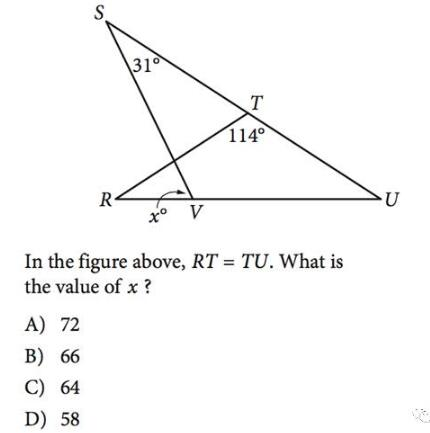

In [53]:
display(Image(filename='/content/ocr.png', width=400))

In [54]:
from PIL import Image

In [55]:
prompt = "<image>\nPlease help me solve this problem step by step."
image_file = "/content/ocr.png"

image_path = os.path.join(model_path, image_file)
print(f"Loading image from {image_path}")
image = Image.open(image_path).convert("RGB")

model_output = run_inference(processor, model, prompt, image, thinking_mode="think")

Loading image from /content/ocr.png
Prompt: <|im_start|>system<|im_sep|>You are Phi, a multimodal model trained by Microsoft to help users.  Your role as an assistant is to provide accurate, coherent, and actionable responses, adapting your reasoning mode (\"NOTHINK\" vs \"THINK\") automatically based on the complexity, clarity, and confidence of each task.\n\n#### NOTHINK Mode\nUse this mode when the task is clear, factual, low-complexity, or can be confidently answered immediately without iterative reasoning. Such as when the input is clear and unambiguous or visual recognition or text comprehension is straightforward, and where a factual, numeric, or short procedural answer is sufficient. Provide a concise, accurate, and confident answer. Please structure your response into one section: using the specified format: <|dummy_84|> {Solution section}. In the Solution section, present the final solution that you deem correct. The Solution section should be logical, accurate, and concise.\

In [56]:
model_output

"<think>1.  **Analyze the given information:**\n    *   We have a figure with points S, R, T, U, V.\n    *   We are given two angles: ∠S = 31° and ∠STU = 114°.\n    *   We are given that RT = TU. This means triangle RTU is an isosceles triangle.\n    *   We need to find the value of angle x, which is ∠RVU.\n\n2.  **Identify relevant geometric properties:**\n    *   **Isosceles Triangle Property:** In an isosceles triangle, the angles opposite the equal sides are equal. Since RT = TU in triangle RTU, the angles opposite these sides are equal: ∠TRU = ∠TUR.\n    *   **Sum of Angles in a Triangle:** The sum of the interior angles of any triangle is 180°.\n    *   **Exterior Angle Theorem:** The measure of an exterior angle of a triangle is equal to the sum of the measures of its two remote interior angles.\n\n3.  **Apply the properties to find unknown angles:**\n    *   Consider triangle RTU. We know RT = TU and ∠STU = 114°.\n    *   Since RT = TU, triangle RTU is isosceles with base RU.\n

---

<!-- CO-OP TRANSLATOR DISCLAIMER START -->
**免责声明**：  
本文件使用 AI 翻译服务 [Co-op Translator](https://github.com/Azure/co-op-translator) 进行翻译。尽管我们力求准确，但请注意，自动翻译可能包含错误或不准确之处。原始语言的原文应被视为权威来源。对于关键信息，建议采用专业人工翻译。我们对因使用本翻译而引起的任何误解或误释概不负责。
<!-- CO-OP TRANSLATOR DISCLAIMER END -->
